## Raw Data Load

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
#import required libraries for data load, manipulation, visaulization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [6]:
#define import and exprot directorirs
RAW_DIR = "D:\Tech\Projects\Visualization\Infosis\Higher-Education-Intelligence-System-for-Institutional-Performance-and-Academic-Excellence-Analysis\Milestone_1/raw"
CLEANED_DIR = "D:\Tech\Projects\Visualization\Infosis\Higher-Education-Intelligence-System-for-Institutional-Performance-and-Academic-Excellence-Analysis\Milestone_1\cleaned"

In [9]:
'''Load 4 raw dataset: 
 ("QS World University Rankings 2025", "THE World University Rankings 2024", 
  "World University Rankings 2023", "World Bank Education Statistics")
'''
try: 
    df_qs = pd.read_csv(f"{RAW_DIR}/qs_2025_raw.csv", encoding="latin-1", low_memory=False)
    df_wb_edu = pd.read_csv(f"{RAW_DIR}/world_bank_education_raw.csv", encoding="latin-1", low_memory=False)
    df_wur = pd.read_csv(f"{RAW_DIR}/wur_2023_raw.csv", encoding="latin-1", low_memory=False)
    df_the = pd.read_csv(f"{RAW_DIR}/the_2024_raw.csv", encoding="latin-1", low_memory=False)
    print('All dataset are loaded successfully')
except Exception as e:
    print(f"Could not read file: {e}")

All dataset are loaded successfully


## Create Dimentions Tables:
**`dim_country.csv`, `dim_university_name.csv`**

### Creation of dim_country table
Build and Export `dim_country.csv`: Combine unique country names, assign country_id, and save directly into *Milestone_1/cleaned/*  

In [314]:
# Identify country columns in each dataset
qs_countries = set(df_qs['Location'].dropna().astype(str).str.strip()) if 'Location' in df_qs.columns else set(df_qs['country'].dropna().astype(str).str.strip())
the_countries = set(df_the['location'].dropna().astype(str).str.strip()) if 'location' in df_the.columns else set(df_the['country'].dropna().astype(str).str.strip())
wur_countries = set(df_wur['Location'].dropna().astype(str).str.strip()) if 'Location' in df_wur.columns else set(df_wur['country'].dropna().astype(str).str.strip())
wb_countries = set(df_wb_edu['Country Name'].dropna().astype(str).str.strip()) if 'Country Name' in df_wb_edu.columns else set(df_wb_edu['country_name'].dropna().astype(str).str.strip())

# Find common standard reference (World Bank Country Names)
reference_countries = wb_countries
print("COUNTRY AUDIT: NAMES NOT DIRECTLY MATCHING WORLD BANK")
reference_countries

COUNTRY AUDIT: NAMES NOT DIRECTLY MATCHING WORLD BANK


{'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Argentina',
 'Armenia',
 'Aruba',
 'Austria',
 'Azerbaijan',
 'Bahrain',
 'Bangladesh',
 'Belarus',
 'Belgium',
 'Belize',
 'Bermuda',
 'Bolivia',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Congo, Dem. Rep.',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'Egypt, Arab Rep.',
 'El Salvador',
 'Estonia',
 'Finland',
 'Georgia',
 'Germany',
 'Ghana',
 'Greenland',
 'Grenada',
 'Guatemala',
 'High income',
 'Honduras',
 'Hong Kong SAR, China',
 'Hungary',
 'India',
 'Indonesia',
 'Iran, Islamic Rep.',
 'Ireland',
 'Israel',
 'Italy',
 'Jamaica',
 'Jordan',
 'Kazakhstan',
 'Korea, Dem. Peopleâ\x80\x99s Rep.',
 'Korea, Rep.',
 'Kuwait',
 'Kyrgyz Republic',
 'Lao PDR',
 'Lebanon',
 'Liechtenstein',
 'Low income',
 'Low

In [8]:
for src_name, c_set in [("QS 2025", qs_countries), ("THE 2024", the_countries), ("WUR 2023", wur_countries)]:
    mismatches = sorted(list(c_set - reference_countries))
    print(f"\n[{src_name}] - {len(mismatches)} Non-Standard Names Found:")
    for name in mismatches:
        print(f"  - '{name}'")


[QS 2025] - 39 Non-Standard Names Found:
  - 'Australia'
  - 'Bosnia and Herzegovina'
  - 'Brunei'
  - 'Canada'
  - 'China (Mainland)'
  - 'Egypt'
  - 'Ethiopia'
  - 'France'
  - 'Greece'
  - 'Hong Kong SAR'
  - 'Iceland'
  - 'Iran, Islamic Republic of'
  - 'Iraq'
  - 'Japan'
  - 'Kenya'
  - 'Kyrgyzstan'
  - 'Latvia'
  - 'Lithuania'
  - 'Luxembourg'
  - 'Macau SAR'
  - 'Netherlands'
  - 'Nigeria'
  - 'Northern Cyprus'
  - 'Palestinian Territory, Occupied'
  - 'Panama'
  - 'Philippines'
  - 'Poland'
  - 'Puerto Rico'
  - 'Russia'
  - 'Slovakia'
  - 'Slovenia'
  - 'South Korea'
  - 'Sudan'
  - 'Taiwan'
  - 'Uganda'
  - 'Ukraine'
  - 'United Arab Emirates'
  - 'United Kingdom'
  - 'Venezuela'

[THE 2024] - 46 Non-Standard Names Found:
  - 'Australia'
  - 'Bosnia and Herzegovina'
  - 'Canada'
  - 'Egypt'
  - 'Ethiopia'
  - 'Fiji'
  - 'France'
  - 'Greece'
  - 'Hong Kong'
  - 'Iceland'
  - 'Iran'
  - 'Iraq'
  - 'Japan'
  - 'Kenya'
  - 'Kosovo'
  - 'Kyrgyzstan'
  - 'Latvia'
  - 'Libya'
  - 

In [9]:
# 1. Standardize Country Names
COUNTRY_MAP = {
    # Territories / Regions / Specific Names
    "China (Mainland)": "China",
    "Hong Kong SAR": "Hong Kong",
    "Macau SAR": "Macau",
    "Macao": "Macau",
    "Taiwan": "Taiwan",
    "Northern Cyprus": "Cyprus",
    "Palestinian Territory, Occupied": "Palestine",
    "Turks and Caicos Islands": "United Kingdom",
    "Puerto Rico": "United States",
    
    # Official / Long-form World Bank Alignments
    "Iran, Islamic Republic of": "Iran",
    "Iran, Islamic Rep.": "Iran",
    "Islamic Republic of Iran": "Iran",
    "South Korea": "Korea, Republic of",
    "Republic of Korea": "Korea, Republic of",
    "Korea, South": "Korea, Republic of",
    "Korea, Dem. People's Rep.": "Korea, Democratic People's Republic of",
    "Russia": "Russian Federation",
    "Russian Federation": "Russian Federation",
    "Egypt, Arab Rep.": "Egypt",
    "Venezuela, RB": "Venezuela",
    "Yemen, Rep.": "Yemen",
    "Slovak Republic": "Slovakia",
    "Czechia": "Czech Republic",
    "Brunei Darussalam": "Brunei",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Macedonia, FYR": "North Macedonia",
    "North Macedonia": "North Macedonia",
    "Congo, Dem. Rep.": "Congo, Democratic Republic of the",
    "Congo, Rep.": "Congo",
    "Syrian Arab Republic": "Syria",
    "Lao PDR": "Laos",
    
    # Common Short-forms
    "USA": "United States",
    "United States of America": "United States",
    "US": "United States",
    "UK": "United Kingdom",
    "Great Britain": "United Kingdom",
    "U.K.": "United Kingdom"
}

In [326]:
# Standardize country Names
def clean_country_name(name):
    if pd.isna(name):
        return np.nan
    s = str(name).strip().lower()
    # Replace common aliases
    if s in COUNTRY_MAP:
        return COUNTRY_MAP[s]
    # Standard Title Case for all other countries
    return str(name).strip().title()

In [12]:
# Identify and clean Country columns
qs_c = (df_qs['Location'] if 'Location' in df_qs.columns else df_qs['country']).apply(clean_country_name)
the_c = (df_the['location'] if 'location' in df_the.columns else df_the['country']).apply(clean_country_name)
wur_c = (df_wur['Location'] if 'Location' in df_wur.columns else df_wur['country']).apply(clean_country_name)
wb_c = (df_wb_edu['Country Name'] if 'Country Name' in df_wb_edu.columns else df_wb_edu['country_name']).apply(clean_country_name)

##### Build dim_country

In [13]:
all_countries = pd.concat([qs_c, the_c, wur_c, wb_c]).dropna().unique()

dim_country = pd.DataFrame({'country_name': sorted(all_countries)})
dim_country['country_id'] = [f"C{str(i+1).zfill(4)}" for i in range(len(dim_country))]

# Rearrange columns
dim_country = dim_country[['country_id', 'country_name']]

# Save deliverable to cleaned folder
#dim_country.to_csv(f"{CLEANED_DIR}/dim_country.csv", index=False)
print(f"[SUCCESS] Exported {CLEANED_DIR}/dim_country.csv with {len(dim_country)} countries.")
dim_country.head()

[SUCCESS] Exported D:\Tech\Projects\Visualization\Infosis\Higher-Education-Intelligence-System-for-Institutional-Performance-and-Academic-Excellence-Analysis\Milestone_1\cleaned/dim_country.csv with 182 countries.


,country_id,country_name
0,C0001,Albania
1,C0002,Algeria
2,C0003,Andorra
3,C0004,Angola
4,C0005,Argentina


In [14]:
dim_country.describe().T

,count,unique,top,freq
country_id,182,182,C0001,1
country_name,182,182,Albania,1


### Creation of dim_university_name table
Build and Export `dim_university.csv`: Pair universities with their standardized country, link country_id, assign university_id, and save to *Milestone_1/cleaned/*  

In [328]:
# 1. Standardize University Names
def clean_university_name(name):
    if pd.isna(name):
        return np.nan
    s = str(name).strip().lower()
    # Remove special punctuation/symbols
    s = re.sub(r"[^\w\s]", "", s)
    # Collapse multiple whitespace characters into single space
    s = re.sub(r"\s+", " ", s).strip()
    return s.title()

In [16]:
# 2. Identify and clean University columns
qs_u = (df_qs['Institution_Name'] if 'Institution_Name' in df_qs.columns else df_qs['institution_name']).apply(clean_university_name)
the_u = (df_the['name'] if 'name' in df_the.columns else df_the['name']).apply(clean_university_name)
wur_u = (df_wur['Name of University'] if 'Name of University' in df_wur.columns else df_wur['university_name']).apply(clean_university_name)

In [17]:
# 3. Create institution-country pairs
qs_pairs = pd.DataFrame({'university_name': qs_u, 'country_name': qs_c})
the_pairs = pd.DataFrame({'university_name': the_u, 'country_name': the_c})
wur_pairs = pd.DataFrame({'university_name': wur_u, 'country_name': wur_c})

# 4. Combine, deduplicate, and sort the pairs in one dataframe
all_unis = (
    pd.concat([qs_pairs, the_pairs, wur_pairs])
    .dropna(subset=['university_name'])
    .drop_duplicates(subset=['university_name'])
    .sort_values('university_name')
    .reset_index(drop=True)
)

In [18]:
all_unis.describe().T

,count,unique,top,freq
university_name,3534,3534,Aalborg University,1
country_name,3533,140,United States,279


In [19]:
# 5. Merge country_id from dim_country
dim_university = all_unis.merge(dim_country, on='country_name', how='left')

# 6. Generate Master University IDs (e.g., U00001, U00002)
dim_university['university_id'] = [f"U{str(i+1).zfill(5)}" for i in range(len(dim_university))]

# Reorder columns
dim_university = dim_university[['university_id', 'university_name', 'country_id', 'country_name']]

# 7. Save deliverable to cleaned folder
#dim_university.to_csv(f"{CLEANED_DIR}/dim_university.csv", index=False)
print(f"[SUCCESS] Exported {CLEANED_DIR}/dim_university.csv with {len(dim_university)} universities.")
dim_university.head(2)

[SUCCESS] Exported D:\Tech\Projects\Visualization\Infosis\Higher-Education-Intelligence-System-for-Institutional-Performance-and-Academic-Excellence-Analysis\Milestone_1\cleaned/dim_university.csv with 3534 universities.


,university_id,university_name,country_id,country_name
0,U00001,Aalborg University,C0042,Denmark
1,U00002,Aalto University,C0051,Finland


In [20]:
dim_university.describe().T

,count,unique,top,freq
university_id,3534,3534,U00001,1
university_name,3534,3534,Aalborg University,1
country_id,3533,140,C0171,279
country_name,3533,140,United States,279


## Creation of Fact Tables: 
**`fact_performace.csv`, `fact_research.csv`, `fact_student.csv`, `fact_country_education.csv`**

### Created University Performance Fact (*fact_university_performance.csv*)
Extracts global ranking and reputation metrics from the QS 2025 datase

In [60]:
df_qs.head(2)

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5


In [23]:
# 1. Prepare QS raw dataset copy
fact_unvrsti_perf =  df_qs.copy()
fact_unvrsti_perf['university_name'] = qs_u

# 2.Merge with dim_university to get university_id
fact_unvrsti_perf = fact_unvrsti_perf.merge(dim_university[['university_name', 'university_id']], on='university_name', how='inner')

In [24]:
fact_unvrsti_perf.head(2)

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score,university_name,university_id
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,143,96.0,58,100.0,8,99.0,15=,100,Massachusetts Institute Of Technology Mit,U01255
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,44,97.4,34,93.4,61,99.7,6,98.5,Imperial College London,U00814


In [25]:
fact_unvrsti_perf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 30 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   str    
 1   RANK_2024                             1482 non-null   str    
 2   Institution_Name                      1503 non-null   str    
 3   Location                              1503 non-null   str    
 4   Region                                1503 non-null   str    
 5   SIZE                                  1503 non-null   str    
 6   FOCUS                                 1503 non-null   str    
 7   RES.                                  1503 non-null   str    
 8   STATUS                                1466 non-null   str    
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   str    
 11  Employer_Reputation_Score   

In [26]:
fact_unvrsti_perf.columns

Index(['RANK_2025', 'RANK_2024', 'Institution_Name', 'Location', 'Region',
       'SIZE', 'FOCUS', 'RES.', 'STATUS', 'Academic_Reputation_Score',
       'Academic_Reputation_Rank', 'Employer_Reputation_Score',
       'Employer_Reputation_Rank', 'Faculty_Student_Score',
       'Faculty_Student_Rank', 'Citations_per_Faculty_Score',
       'Citations_per_Faculty_Rank', 'International_Faculty_Score',
       'International_Faculty_Rank', 'International_Students_Score',
       'International_Students_Rank', 'International_Research_Network_Score',
       'International_Research_Network_Rank', 'Employment_Outcomes_Score',
       'Employment_Outcomes_Rank', 'Sustainability_Score',
       'Sustainability_Rank', 'Overall_Score', 'university_name',
       'university_id'],
      dtype='str')

In [27]:
fact_unvrsti_perf.columns = fact_unvrsti_perf.columns.str.lower().str.replace({" ": "_","_score":"",".":""}).str.strip()
fact_unvrsti_perf.columns

Index(['rank_2025', 'rank_2024', 'institution_name', 'location', 'region',
       'size', 'focus', 'res', 'status', 'academic_reputation',
       'academic_reputation_rank', 'employer_reputation',
       'employer_reputation_rank', 'faculty_student', 'faculty_student_rank',
       'citations_per_faculty', 'citations_per_faculty_rank',
       'international_faculty', 'international_faculty_rank',
       'international_students', 'international_students_rank',
       'international_research_network', 'international_research_network_rank',
       'employment_outcomes', 'employment_outcomes_rank', 'sustainability',
       'sustainability_rank', 'overall', 'university_name', 'university_id'],
      dtype='str')

In [28]:
fact_unvrsti_perf.isnull().sum()

rank_2025                                0
rank_2024                               21
institution_name                         0
location                                 0
region                                   0
size                                     0
focus                                    0
res                                      0
status                                  37
academic_reputation                      0
academic_reputation_rank                 0
employer_reputation                      0
employer_reputation_rank                 0
faculty_student                          0
faculty_student_rank                     0
citations_per_faculty                    0
citations_per_faculty_rank               0
international_faculty                  100
international_faculty_rank             100
international_students                  58
international_students_rank             58
international_research_network           1
international_research_network_rank      1
employment_

In [29]:
print("Null Values:" ,fact_unvrsti_perf.isnull().sum().sum())
print("Percentage:", fact_unvrsti_perf.isnull().sum().sum() / fact_unvrsti_perf.size * 100)

Null Values: 1316
Percentage: 2.918607229984475


In [30]:
fact_unvrsti_perf['rank_2025'].value_counts().head(2)

rank_2025
1201-1400    199
1001-1200    197
Name: count, dtype: int64

In [31]:
fact_unvrsti_perf['rank_2025'] = fact_unvrsti_perf['rank_2025'].astype(str).str.extract(r'(\d+)')[0].astype(float)

In [32]:
fact_unvrsti_perf['rank_2025'].isnull().sum()

0

In [33]:
fact_unvrsti_perf['rank_2024'].value_counts().head(2)

rank_2024
1201-1400    206
1001-1200    199
Name: count, dtype: int64

In [34]:
fact_unvrsti_perf['rank_2024'] = fact_unvrsti_perf['rank_2024'].astype(str).str.extract(r'(\d+)')[0].astype(float)

In [35]:
fact_unvrsti_perf['rank_2024'].isnull().sum()

21

Text(0.5, 1.0, 'Rank_2024 Distribution')

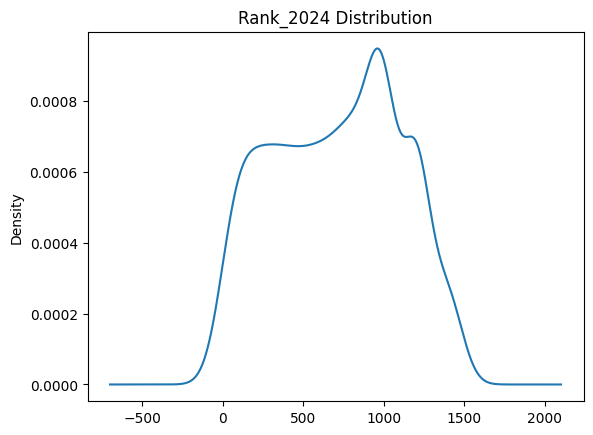

In [36]:
fact_unvrsti_perf['rank_2024'].plot(kind='kde')
plt.title('Rank_2024 Distribution')

In [37]:
rank_24_mean = fact_unvrsti_perf['rank_2024'].mean()
fact_unvrsti_perf['rank_2024'] = fact_unvrsti_perf['rank_2024'].fillna(rank_24_mean, inplace=True)

In [38]:
fact_unvrsti_perf['rank_2024'].isnull().sum()

0

In [39]:
fact_unvrsti_perf['rank_changed_24-25'] = fact_unvrsti_perf['rank_2024'] - fact_unvrsti_perf['rank_2025']

In [40]:
fact_unvrsti_perf['rank_changed_24-25']

0         0.0
1         4.0
2         0.0
3         0.0
4        -3.0
        ...  
1498   -200.0
1499      0.0
1500   -200.0
1501      0.0
1502      0.0
Name: rank_changed_24-25, Length: 1503, dtype: float64

In [41]:
fact_unvrsti_perf['overall'].dtype

<StringDtype(na_value=nan)>

In [42]:
fact_unvrsti_perf['overall'] = pd.to_numeric(fact_unvrsti_perf['overall'], errors='coerce')

In [43]:
fact_unvrsti_perf['overall'].dtype

dtype('float64')

In [44]:
fact_unvrsti_perf['overall'].isnull().sum()

903

Text(0.5, 1.0, 'QS_overall_score')

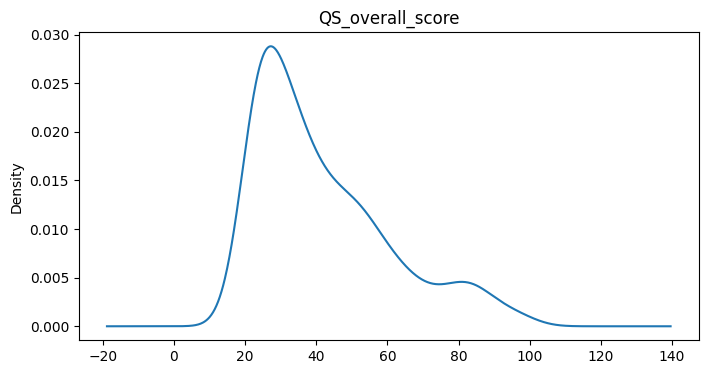

In [45]:
plt.figure(figsize = (8,4))
fact_unvrsti_perf['overall'].plot(kind='kde')
plt.title('QS_overall_score')

In [46]:
fact_unvrsti_perf.columns

Index(['rank_2025', 'rank_2024', 'institution_name', 'location', 'region',
       'size', 'focus', 'res', 'status', 'academic_reputation',
       'academic_reputation_rank', 'employer_reputation',
       'employer_reputation_rank', 'faculty_student', 'faculty_student_rank',
       'citations_per_faculty', 'citations_per_faculty_rank',
       'international_faculty', 'international_faculty_rank',
       'international_students', 'international_students_rank',
       'international_research_network', 'international_research_network_rank',
       'employment_outcomes', 'employment_outcomes_rank', 'sustainability',
       'sustainability_rank', 'overall', 'university_name', 'university_id',
       'rank_changed_24-25'],
      dtype='str')

In [47]:
# QS Official Weighting Methodology
weights = {
    "academic_reputation": 0.30,  # 30%
    "employer_reputation": 0.15,  # 15%
    "faculty_student": 0.10,  # 10%
    "international_faculty": 0.05,  # 5%
    "international_students": 0.05,  # 5%
    "international_research_network": 0.05,  # 5%
    "employment_outcomes": 0.05,  # 5%
    "sustainability": 0.05,  # 5%
}
# 1. Calculate the theoretical weighted score
calculated_score = sum(
    fact_unvrsti_perf[col].astype(float) * weight for col, weight in weights.items()
)

In [48]:
# 2. Fill missing overall values with calculated composite score
fact_unvrsti_perf["overall"] = fact_unvrsti_perf["overall"].fillna(
    calculated_score.round(2)
)

In [49]:
fact_unvrsti_perf['overall'].isnull().sum().sum() / fact_unvrsti_perf.size *100

0.24467194642972123

In [50]:
print("Null Values:" ,fact_unvrsti_perf.isnull().sum().sum())
print("Percentage:", fact_unvrsti_perf.isnull().sum().sum() / fact_unvrsti_perf.size * 100)

Null Values: 507
Percentage: 1.0881462880690231


In [51]:
fact_unvrsti_perf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   rank_2025                            1503 non-null   float64
 1   rank_2024                            1503 non-null   float64
 2   institution_name                     1503 non-null   str    
 3   location                             1503 non-null   str    
 4   region                               1503 non-null   str    
 5   size                                 1503 non-null   str    
 6   focus                                1503 non-null   str    
 7   res                                  1503 non-null   str    
 8   status                               1466 non-null   str    
 9   academic_reputation                  1503 non-null   float64
 10  academic_reputation_rank             1503 non-null   str    
 11  employer_reputation                  1503

In [52]:
# Add metadata and standardize numeric columns
fact_unvrsti_perf['year_2025'] = 2025
fact_unvrsti_perf['global_rank_2025'] = pd.to_numeric(fact_unvrsti_perf['rank_2025'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
fact_unvrsti_perf['global_rank_2024'] = pd.to_numeric(fact_unvrsti_perf['rank_2024'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
fact_unvrsti_perf['academic_reputation'] = pd.to_numeric(fact_unvrsti_perf['academic_reputation'], errors='coerce')
fact_unvrsti_perf['employer_reputation'] = pd.to_numeric(fact_unvrsti_perf['employer_reputation'], errors='coerce')

In [53]:
fact_unvrsti_perf.columns

Index(['rank_2025', 'rank_2024', 'institution_name', 'location', 'region',
       'size', 'focus', 'res', 'status', 'academic_reputation',
       'academic_reputation_rank', 'employer_reputation',
       'employer_reputation_rank', 'faculty_student', 'faculty_student_rank',
       'citations_per_faculty', 'citations_per_faculty_rank',
       'international_faculty', 'international_faculty_rank',
       'international_students', 'international_students_rank',
       'international_research_network', 'international_research_network_rank',
       'employment_outcomes', 'employment_outcomes_rank', 'sustainability',
       'sustainability_rank', 'overall', 'university_name', 'university_id',
       'rank_changed_24-25', 'year_2025', 'global_rank_2025',
       'global_rank_2024'],
      dtype='str')

In [54]:
fact_unvrsti_perf.columns

Index(['rank_2025', 'rank_2024', 'institution_name', 'location', 'region',
       'size', 'focus', 'res', 'status', 'academic_reputation',
       'academic_reputation_rank', 'employer_reputation',
       'employer_reputation_rank', 'faculty_student', 'faculty_student_rank',
       'citations_per_faculty', 'citations_per_faculty_rank',
       'international_faculty', 'international_faculty_rank',
       'international_students', 'international_students_rank',
       'international_research_network', 'international_research_network_rank',
       'employment_outcomes', 'employment_outcomes_rank', 'sustainability',
       'sustainability_rank', 'overall', 'university_name', 'university_id',
       'rank_changed_24-25', 'year_2025', 'global_rank_2025',
       'global_rank_2024'],
      dtype='str')

In [55]:
cols_to_keep = [
        'university_id',
        'university_name',
        'year_2025',
        'global_rank_2025',
        'global_rank_2024',
        'overall',
        'rank_changed_24-25',
        'size', 
        'focus', 
        'res', 
        'academic_reputation',
        'employer_reputation']

In [56]:
fact_university_performance = fact_unvrsti_perf[cols_to_keep]

In [57]:
fact_university_performance.columns

Index(['university_id', 'university_name', 'year_2025', 'global_rank_2025',
       'global_rank_2024', 'overall', 'rank_changed_24-25', 'size', 'focus',
       'res', 'academic_reputation', 'employer_reputation'],
      dtype='str')

In [58]:
fact_university_performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   university_id        1503 non-null   str    
 1   university_name      1503 non-null   str    
 2   year_2025            1503 non-null   int64  
 3   global_rank_2025     1503 non-null   int64  
 4   global_rank_2024     1503 non-null   int64  
 5   overall              1389 non-null   float64
 6   rank_changed_24-25   1503 non-null   float64
 7   size                 1503 non-null   str    
 8   focus                1503 non-null   str    
 9   res                  1503 non-null   str    
 10  academic_reputation  1503 non-null   float64
 11  employer_reputation  1503 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 200.4 KB


In [59]:
null_count = fact_university_performance.isnull().sum().sum()
null_per = (fact_university_performance.isnull().sum().sum() / fact_university_performance.size) * 100

print("Total null values:", null_count)
print("Percentage of Null value:", null_per)

Total null values: 114
Percentage of Null value: 0.6320691949434464


In [60]:
fact_university_performance[fact_university_performance.duplicated()]

,university_id,university_name,year_2025,global_rank_2025,global_rank_2024,overall,rank_changed_24-25,size,focus,res,academic_reputation,employer_reputation


In [61]:
fact_university_performance['size'].value_counts()

size
L     691
M     372
XL    352
S      88
Name: count, dtype: int64

In [62]:
fact_university_performance['size'] = fact_university_performance['size'].replace({ 'L':'Large' , 'M':'Medium','XL':'Extra Large','S':'Small'}, inplace = True)

In [63]:
fact_university_performance['size'].value_counts()

size
Large          691
Medium         372
Extra Large    352
Small           88
Name: count, dtype: int64

In [64]:
fact_university_performance['focus'].value_counts()

focus
FC    592
CO    480
FO    353
SP     78
Name: count, dtype: int64

In [65]:
fact_university_performance['focus'] = fact_university_performance['focus'].replace({ 'FC':'Full Comprehensive' , 'CO':'Comprehensive','FO':'Foucsed','SP':'Specialist'}, inplace = True)

In [66]:
fact_university_performance['focus'].value_counts()

focus
Full Comprehensive    592
Comprehensive         480
Foucsed               353
Specialist             78
Name: count, dtype: int64

In [67]:
fact_university_performance['res'].value_counts()

res
VH    1021
HI     362
MD     104
LO      16
Name: count, dtype: int64

In [68]:
fact_university_performance['res'] = fact_university_performance['res'].replace({ 'VH':'Very High' , 'HI':'High','MD':'Medium','LO':'Low'}, inplace = True)

In [69]:
fact_university_performance['res'].value_counts()

res
Very High    1021
High          362
Medium        104
Low            16
Name: count, dtype: int64

In [70]:
fact_university_performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   university_id        1503 non-null   str    
 1   university_name      1503 non-null   str    
 2   year_2025            1503 non-null   int64  
 3   global_rank_2025     1503 non-null   int64  
 4   global_rank_2024     1503 non-null   int64  
 5   overall              1389 non-null   float64
 6   rank_changed_24-25   1503 non-null   float64
 7   size                 1503 non-null   str    
 8   focus                1503 non-null   str    
 9   res                  1503 non-null   str    
 10  academic_reputation  1503 non-null   float64
 11  employer_reputation  1503 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 233.2 KB


In [71]:
fact_university_performance.describe().T

,count,mean,std,min,25%,50%,75%,max
year_2025,1503.0,2025.000000,0.000000,2025.000000,2025.00,2025.00,2025.0,2025.0
global_rank_2025,1503.0,716.898869,399.086239,1.000000,376.00,741.00,1001.0,1401.0
global_rank_2024,1503.0,708.517631,391.021365,1.000000,375.00,731.00,1001.0,1401.0
overall,1389.0,23.934989,20.211355,2.480000,9.05,16.46,32.8,100.0
rank_changed_24-25,1503.0,-8.373903,93.631958,-692.475034,-30.00,0.00,10.0,1021.0
academic_reputation,1503.0,20.286693,22.326168,1.300000,6.30,11.00,23.5,100.0
employer_reputation,1503.0,19.787292,23.784738,1.100000,4.30,9.40,25.3,100.0


In [72]:
# # Export deliverable
# #fact_university_performance.to_csv(f"{CLEANED_DIR}/fact_university_performance.csv", index=False)
# print(f"[SUCCESS] Exported fact_university_performance.csv: {fact_university_performance.shape}")
# fact_university_performance.head(2)

### Created Research Fact (*fact_research.csv*)
`Extracted research metrics and transparently computed the derived Research Productivity Index from THE 2024

In [74]:
# 1. Prepare THE raw dataset copy
fact_res = df_the.copy()

In [75]:
fact_res['university_name'] = the_u
fact_res.head(2)

,rank,name,scores_overall,scores_overall_rank,scores_teaching,scores_teaching_rank,scores_research,scores_research_rank,scores_citations,scores_citations_rank,...,stats_student_staff_ratio,stats_pc_intl_students,stats_female_male_ratio,aliases,subjects_offered,closed,unaccredited,disabled,website_url,university_name
0,1,University of Oxford,98.5,10,96.6,5,100.0,2,99.0,5,...,10.9,42%,49:51:00,University of Oxford,"Geography,Chemistry,Chemical Engineering,Biolo...",False,False,False,https://www.timeshighereducation.com/student/r...,University Of Oxford
1,2,Stanford University,98,20,99.0,1,97.8,8,99.6,2,...,6.4,23%,47:53:00,Stanford University,"Computer Science,Communication & Media Studies...",False,False,False,NaN,Stanford University


In [76]:
fact_res.columns

Index(['rank', 'name', 'scores_overall', 'scores_overall_rank',
       'scores_teaching', 'scores_teaching_rank', 'scores_research',
       'scores_research_rank', 'scores_citations', 'scores_citations_rank',
       'scores_industry_income', 'scores_industry_income_rank',
       'scores_international_outlook', 'scores_international_outlook_rank',
       'record_type', 'member_level', 'url', 'nid', 'location',
       'stats_number_students', 'stats_student_staff_ratio',
       'stats_pc_intl_students', 'stats_female_male_ratio', 'aliases',
       'subjects_offered', 'closed', 'unaccredited', 'disabled', 'website_url',
       'university_name'],
      dtype='str')

In [77]:
fact_res.info()

<class 'pandas.DataFrame'>
RangeIndex: 2673 entries, 0 to 2672
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   rank                               2673 non-null   str    
 1   name                               2673 non-null   str    
 2   scores_overall                     1904 non-null   str    
 3   scores_overall_rank                2673 non-null   int64  
 4   scores_teaching                    1904 non-null   float64
 5   scores_teaching_rank               2673 non-null   int64  
 6   scores_research                    1904 non-null   float64
 7   scores_research_rank               2673 non-null   int64  
 8   scores_citations                   1904 non-null   float64
 9   scores_citations_rank              2673 non-null   int64  
 10  scores_industry_income             1904 non-null   float64
 11  scores_industry_income_rank        2673 non-null   int64  
 12  sco

In [78]:
# 2. Merge with dim_university
fact_res = fact_res.merge(dim_university[['university_name', 'university_id']], on='university_name', how='inner')

In [79]:
fact_res.columns

Index(['rank', 'name', 'scores_overall', 'scores_overall_rank',
       'scores_teaching', 'scores_teaching_rank', 'scores_research',
       'scores_research_rank', 'scores_citations', 'scores_citations_rank',
       'scores_industry_income', 'scores_industry_income_rank',
       'scores_international_outlook', 'scores_international_outlook_rank',
       'record_type', 'member_level', 'url', 'nid', 'location',
       'stats_number_students', 'stats_student_staff_ratio',
       'stats_pc_intl_students', 'stats_female_male_ratio', 'aliases',
       'subjects_offered', 'closed', 'unaccredited', 'disabled', 'website_url',
       'university_name', 'university_id'],
      dtype='str')

In [80]:
print('Total Null values:', fact_res.isnull().sum().sum())
print('Percentage:', fact_res.isnull().sum().sum() / fact_res.size * 100)

Total Null values: 7040
Percentage: 8.495951148280897


In [81]:
miss_col = [i for i in fact_res.columns if fact_res[i].isnull().sum() > 0 ]
fact_res[miss_col].isnull().sum()

scores_overall                   769
scores_teaching                  769
scores_research                  769
scores_citations                 769
scores_industry_income           769
scores_international_outlook     769
stats_female_male_ratio           93
subjects_offered                   4
website_url                     2329
dtype: int64

In [82]:
# Add metadata and convert numeric indicators
fact_res['year'] = 2024
fact_res['research_score'] = pd.to_numeric(fact_res['scores_research'], errors='coerce')
fact_res['research_impact'] = pd.to_numeric(fact_res['scores_citations'],errors='coerce')  # Benchmark research impact

In [83]:
fact_res.columns

Index(['rank', 'name', 'scores_overall', 'scores_overall_rank',
       'scores_teaching', 'scores_teaching_rank', 'scores_research',
       'scores_research_rank', 'scores_citations', 'scores_citations_rank',
       'scores_industry_income', 'scores_industry_income_rank',
       'scores_international_outlook', 'scores_international_outlook_rank',
       'record_type', 'member_level', 'url', 'nid', 'location',
       'stats_number_students', 'stats_student_staff_ratio',
       'stats_pc_intl_students', 'stats_female_male_ratio', 'aliases',
       'subjects_offered', 'closed', 'unaccredited', 'disabled', 'website_url',
       'university_name', 'university_id', 'year', 'research_score',
       'research_impact'],
      dtype='str')

In [84]:
# Select required schema
fact_res_cols = ['university_id', 'year', 'research_score', 'research_impact']
fact_research = fact_res[fact_res_cols]

In [85]:
fact_research.isnull().sum()

university_id        0
year                 0
research_score     769
research_impact    769
dtype: int64

In [86]:
miss_col = [i for i in fact_research.columns if fact_research[i].isnull().sum() > 0 &  fact_research[i].isnull().sum() < .05]
fact_research[miss_col].isnull().sum() / fact_research.size * 100

research_score     7.192293
research_impact    7.192293
dtype: float64

**Leave missing values as NaN:** \
**Justify:** In Tableau, calculated fields like `AVG([research_score]` will ignore null values rather than distorting true institutional performance averages or creating artificial scatter-plot clusters

In [88]:
# Compute transparent composite Research Productivity Index
fact_research['research_productivity'] = (
    (fact_research['research_score'] * 0.5) + (fact_research['research_impact'] * 0.5)
).round(2)

In [89]:
fact_research.columns

Index(['university_id', 'year', 'research_score', 'research_impact',
       'research_productivity'],
      dtype='str')

In [90]:
fact_research[fact_research.duplicated()]

,university_id,year,research_score,research_impact,research_productivity


In [91]:
fact_research.info()

<class 'pandas.DataFrame'>
RangeIndex: 2673 entries, 0 to 2672
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   university_id          2673 non-null   str    
 1   year                   2673 non-null   int64  
 2   research_score         1904 non-null   float64
 3   research_impact        1904 non-null   float64
 4   research_productivity  1904 non-null   float64
dtypes: float64(3), int64(1), str(1)
memory usage: 120.5 KB


In [193]:
# Export deliverable
#fact_research.to_csv(f"{CLEANED_DIR}/fact_research.csv", index=False)
print(f"[SUCCESS] Exported fact_research.csv: {fact_research.shape}")
fact_research.head()

[SUCCESS] Exported fact_research.csv: (2673, 5)


,university_id,year,research_score,research_impact,research_productivity
0,U02990,2024,100.0,99.0,99.50
1,U01937,2024,97.8,99.6,98.70
2,U01254,2024,96.2,99.7,97.95
3,U00738,2024,99.9,99.4,99.65
4,U02662,2024,100.0,98.0,99.00


### Created Student Fact (*fact_student.csv*)
Extracted student and staff numbers and computed the percentage of international students from WUR 2023:  

In [200]:
fact_stu = df_wur.copy()

In [212]:
fact_stu.head(2)

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score,university_name,university_id
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2,University Of Oxford,U02990
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5,Harvard University,U00738


In [204]:
fact_stu['university_name'] = wur_u
fact_stu.head(2)

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score,university_name
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2,University Of Oxford
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5,Harvard University


In [206]:
# 2. Merge with dim_university
fact_stu = fact_stu.merge(dim_university[['university_name', 'university_id']], on='university_name', how='inner')
fact_stu.head(2)

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score,university_name,university_id
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2,University Of Oxford,U02990
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5,Harvard University,U00738


In [214]:
fact_stu.info()

<class 'pandas.DataFrame'>
RangeIndex: 2233 entries, 0 to 2232
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Rank              2233 non-null   str    
 1   Name of University           2233 non-null   str    
 2   Location                     2047 non-null   str    
 3   No of student                2209 non-null   str    
 4   No of student per staff      2208 non-null   float64
 5   International Student        2209 non-null   str    
 6   Female:Male Ratio            2128 non-null   str    
 7   OverAll Score                1721 non-null   str    
 8   Teaching Score               1721 non-null   float64
 9   Research Score               1721 non-null   float64
 10  Citations Score              1721 non-null   float64
 11  Industry Income Score        1721 non-null   float64
 12  International Outlook Score  1721 non-null   float64
 13  university_name              

In [216]:
fact_stu.isnull().sum()

University Rank                  0
Name of University               0
Location                       186
No of student                   24
No of student per staff         25
International Student           24
Female:Male Ratio              105
OverAll Score                  512
Teaching Score                 512
Research Score                 512
Citations Score                512
Industry Income Score          512
International Outlook Score    512
university_name                  0
university_id                    0
dtype: int64

In [224]:
fact_stu['No of student per staff'].value_counts().head(5)

No of student per staff
15.4    21
14.2    19
14.7    19
16.0    19
17.0    19
Name: count, dtype: int64

In [226]:
fact_stu['No of student'].value_counts().head(5)

No of student
20,185    2
16,758    2
20,620    2
31,545    2
27,105    2
Name: count, dtype: int64

In [228]:
fact_stu['International Student'].value_counts().head(5)

International Student
0%    336
1%    289
2%    196
3%    148
4%    115
Name: count, dtype: int64

In [232]:
# Add metadata and clean numeric/string formats
fact_stu['year'] = 2023
fact_stu['total_students'] = pd.to_numeric(fact_stu['No of student'].astype(str).str.replace(',', ''), errors='coerce')
fact_stu['students_per_staff'] = pd.to_numeric(fact_stu['No of student per staff'], errors='coerce')

# Parse percentage strings like "24%" into numeric values
fact_stu['international_student_percentage'] = pd.to_numeric(
    fact_stu['International Student'].astype(str).str.replace('%', '').str.strip(), 
    errors='coerce'
)

In [236]:
fact_stu.head(2)

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score,university_name,university_id,year,total_students,students_per_staff,international_student_percentage
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2,University Of Oxford,U02990,2023,20965.0,10.6,42.0
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5,Harvard University,U00738,2023,21887.0,9.6,25.0


In [240]:
# Calculate total count of international students
fact_stu['international_students'] = fact_stu['total_students'] * (fact_stu['international_student_percentage'] / 100).round(0)

In [242]:
fact_stu.info()

<class 'pandas.DataFrame'>
RangeIndex: 2233 entries, 0 to 2232
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   University Rank                   2233 non-null   str    
 1   Name of University                2233 non-null   str    
 2   Location                          2047 non-null   str    
 3   No of student                     2209 non-null   str    
 4   No of student per staff           2208 non-null   float64
 5   International Student             2209 non-null   str    
 6   Female:Male Ratio                 2128 non-null   str    
 7   OverAll Score                     1721 non-null   str    
 8   Teaching Score                    1721 non-null   float64
 9   Research Score                    1721 non-null   float64
 10  Citations Score                   1721 non-null   float64
 11  Industry Income Score             1721 non-null   float64
 12  International Out

In [244]:
# Select required schema
fact_stu_cols = ['university_id', 'year', 'total_students', 'students_per_staff', 'international_students', 'international_student_percentage']
fact_student = fact_stu[fact_stu_cols].drop_duplicates()

In [246]:
fact_student.info()

<class 'pandas.DataFrame'>
RangeIndex: 2233 entries, 0 to 2232
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   university_id                     2233 non-null   str    
 1   year                              2233 non-null   int64  
 2   total_students                    2209 non-null   float64
 3   students_per_staff                2208 non-null   float64
 4   international_students            2206 non-null   float64
 5   international_student_percentage  2206 non-null   float64
dtypes: float64(4), int64(1), str(1)
memory usage: 118.2 KB


In [248]:
fact_student.isnull().sum()

university_id                        0
year                                 0
total_students                      24
students_per_staff                  25
international_students              27
international_student_percentage    27
dtype: int64

In [250]:
print('Total NaN values:',fact_student.isnull().sum().sum())
print('Percentage of NaN:',fact_student.isnull().sum().sum() / fact_student.size *100)

Total NaN values: 103
Percentage of NaN: 0.7687714584266309


**Leave missing values as NaN:** \
**Justify:** There are less than 2% missing values and in Tableau, calculated fields like `AVG([international_student]` will ignore null values rather
than distorting true institutional performance averages or creating artificial scatter-plot clusters

In [255]:
# Export deliverable
#fact_student.to_csv(f"{CLEANED_DIR}/fact_student.csv", index=False)
print(f"[SUCCESS] Exported fact_student.csv: {fact_student.shape}")
fact_student.head()

[SUCCESS] Exported fact_student.csv: (2233, 6)


,university_id,year,total_students,students_per_staff,international_students,international_student_percentage
0,U02990,2023,20965.0,10.6,0.0,42.0
1,U00738,2023,21887.0,9.6,0.0,25.0
2,U02662,2023,20185.0,11.3,0.0,39.0
3,U01937,2023,16164.0,7.1,0.0,24.0
4,U01254,2023,11415.0,8.2,0.0,33.0


### Created Country Education Fact (*fact_country_education.csv*)
Standardizes country metrics from World Bank Education statistics and joins with dim_country

In [274]:
df_wb_edu.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  162 non-null    str    
 1   Country Code  162 non-null    str    
 2   indicator     162 non-null    str    
 3   year          162 non-null    int64  
 4   value         162 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 16.3 KB


In [294]:
#Prepare World Bank dataset copy
fact_wb = df_wb_edu.copy()
fact_wb['country_name'] = wb_c
fact_wb.head(2)

,country_name,Country Code,indicator,year,value
0,High Income,HIC,"Gross enrolment ratio, tertiary, both sexes (%)",2015,73.746918
1,Low Income,LIC,"Gross enrolment ratio, tertiary, both sexes (%)",2015,7.626870


In [278]:
fact_wb.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  162 non-null    str    
 1   Country Code  162 non-null    str    
 2   indicator     162 non-null    str    
 3   year          162 non-null    int64  
 4   value         162 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 16.3 KB


In [282]:
dim_country.info()

<class 'pandas.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   country_id    182 non-null    str  
 1   country_name  182 non-null    str  
dtypes: str(2)
memory usage: 5.5 KB


In [292]:
# Merge with dim_country to attach country_id
fact_country_ed = fact_wb.merge(dim_country[['country_name', 'country_id']], on='country_name', how='inner')
fact_country_ed.head(2)

,country_name,Country Code,indicator,year,value,country_id
0,High Income,HIC,"Gross enrolment ratio, tertiary, both sexes (%)",2015,73.746918,C0060
1,Low Income,LIC,"Gross enrolment ratio, tertiary, both sexes (%)",2015,7.626870,C0093


In [296]:
fact_country_ed.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  162 non-null    str    
 1   Country Code  162 non-null    str    
 2   indicator     162 non-null    str    
 3   year          162 non-null    int64  
 4   value         162 non-null    float64
 5   country_id    162 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 18.4 KB


In [300]:
#Select required schema
fact_country_education = fact_country_ed[['country_id', 'year', 'indicator', 'value']].dropna(subset=['value'])
fact_country_education.head(2)

,country_id,year,indicator,value
0,C0060,2015,"Gross enrolment ratio, tertiary, both sexes (%)",73.746918
1,C0093,2015,"Gross enrolment ratio, tertiary, both sexes (%)",7.626870


In [302]:
fact_country_education.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country_id  162 non-null    str    
 1   year        162 non-null    int64  
 2   indicator   162 non-null    str    
 3   value       162 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 13.9 KB


In [304]:
fact_country_education.isnull().sum().sum()

0

In [306]:
fact_country_education[fact_country_education.duplicated()]

,country_id,year,indicator,value


In [15]:
# Export deliverable
#fact_country_education.to_csv(f"{CLEANED_DIR}/fact_country_education.csv", index=False)
print(f"[SUCCESS] Exported fact_country_education.csv: {fact_country_education.shape}")
fact_country_education.head()

NameError: name 'fact_country_education' is not defined